# Kaggle Mushrooms Dataset
Source: https://www.kaggle.com/datasets/dariobaumberger/combined-kaggle-mushrooms-dataset/data

Credit for merge effort: https://github.com/dario-baumberger/combined-kaggle-mushrooms-dataset

---

### Libraries & Packages

In [54]:
# path for photo inventory
from pathlib import Path

# for opening images
from PIL import Image, UnidentifiedImageError
import re

# plots
import math
import matplotlib.pyplot as plt

# core 
import numpy as np
import pandas as pd

# PyTorch
from torchvision import transforms # image transforms
from torchvision.datasets import ImageFolder # PyTorch image folder loader
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch.utils.data import DataLoader # PyTorch batching

# PyTorch model setup
import torch
import torch.nn as nn
from torchvision import models

### Project Paths and Settings

In [55]:
# relative path and image extension
image_folder = Path(r"../GroupProject/images")
image_extension = ".webp" # all images are .webp
SEED = 67

In [56]:
# check path for `image` folder to load nested folder structure
print(image_folder.resolve())
print(image_folder.exists())

/Users/luisa/Desktop/DM2project/GroupProject/images
True


---

# EDA
- Learn structure of image set
- Pre-processing decisions
- Main purpose is to lead into PyTorch ImageFolder setup to flow into train/test splits -> feature extraction -> baseline model -> other models -> comparison

### Table:
- file_path
- folder
- genus
- species
- label_type
- img_number
- width
- height
- aspect_ratio
- valid_image (means PIL can open/read image size)

In [57]:
folders_without_space = [
    class_dir.name
    for class_dir in sorted(image_folder.iterdir())
    if class_dir.is_dir() and " " not in class_dir.name
]

print("folders without space:", len(folders_without_space))
folders_without_space[:50]

folders without space: 4


['Chroogomphus', 'Clavariaceae', 'Clavulinaceae', 'Pleurotus']

In [58]:
# load metadata df directly if it exists
metadata_file = Path("image_metadata.parquet")

if metadata_file.exists():
    df = pd.read_parquet(metadata_file)
    print("loaded metadata:", metadata_file)

# or else create the dataframe and save it
else:

# empty rows list to fill metadata table
    rows = []

    # loop through each folder
    for class_dir in sorted(image_folder.iterdir()):
        if not class_dir.is_dir():
            continue

        # pull folder name and split possible genus/species
        folder = class_dir.name
        folder_parts = folder.split(" ", 1)

        # binomial label: Genus | species
        if len(folder_parts) == 2:
            genus = folder_parts[0]
            species = folder_parts[1]
            label_type = "binomial"

        # single label folders: genus/family/etc. only
        else:
            genus = folder
            species = None
            label_type = "non_binomial"

        # loop through images inside current label folder
        for img_path in sorted(class_dir.glob(f"*{image_extension}")):
            img_number = int(img_path.stem.rsplit("_", 1)[1])

            # try opening image and pulling size metadata
            try:
                with Image.open(img_path) as img:
                    width, height = img.size

                valid_image = True
                aspect_ratio = width / height
            
            # mark image invalid if metadata cannot be read
            except (UnidentifiedImageError, OSError):
                width = None
                height = None
                aspect_ratio = None
                valid_image = False
            
            # add one image row to metadata table
            rows.append({
                "file_path": str(img_path),
                "folder": folder,
                "genus": genus,
                "species": species,
                "label_type": label_type,
                "img_number": img_number,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "valid_image": valid_image
            })

    # save metadata rows as DataFrame
    df = pd.DataFrame(rows)
    df.to_parquet(metadata_file)
    print("created metadata:", metadata_file)

loaded metadata: image_metadata.parquet


In [59]:
print("total images:", len(df))
print("valid images:", df["valid_image"].sum())
print("invalid images:", (~df["valid_image"]).sum())
print(df["label_type"].value_counts()) #image counts

total images: 195411
valid images: 195411
invalid images: 0
label_type
binomial        195271
non_binomial       140
Name: count, dtype: int64


In [60]:
# checking table for EDA
df = df.sort_values(["folder", "img_number"]).reset_index(drop=True)
df.head()

,file_path,folder,genus,species,label_type,img_number,width,height,aspect_ratio,valid_image
0,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,1,100,100,1.0,True
1,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,2,100,100,1.0,True
2,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,3,100,100,1.0,True
3,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,4,100,100,1.0,True
4,..\GroupProject\images\Agaricus arvensis\Agari...,Agaricus arvensis,Agaricus,arvensis,binomial,5,100,100,1.0,True


### Species / Genus Distribution

This section summarizes how images are distributed between class labels and genus groups.

Each folder is a class label since PyTorch will use the folder names as the target classes. Though, Genus and species are parsed from the folder names for EDA.

The goal is here is to check dataset balance for later preprocessing decisions like stratifiied splits, and evaluation metric choice.

Key questions:
- How many folder-based class labels are present?
- How many genus groups are present?
- Which classes dominate the dataset?
- Which classes are underrepresented?
- Are any labels non-binomial or structurally unusual?
- Should train/test splitting be stratified by class?
- Should evaluation include macro-F1 instead of relying only on accuracy?

In [61]:
# Make tables for separate analysis between species and genus

# makes df with genus, species, label, and adds image count
species_counts = (
    df.groupby("folder")
    .agg(
        genus=("genus", "first"),
        species=("species", "first"),
        label_type=("label_type", "first"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# makes df with genus, species_count, and adds image count
genus_counts = (
    df.groupby("genus")
    .agg(
        species_count=("folder", "nunique"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# totals
print("folder/class labels:", species_counts["folder"].nunique())
print("binomial labels:", (species_counts["label_type"] == "binomial").sum())
print("non-binomial labels:", (species_counts["label_type"] == "non_binomial").sum())
print("unique species labels:", species_counts["species"].nunique())
print("unique genus labels:", genus_counts["genus"].nunique())

folder/class labels: 555
binomial labels: 551
non-binomial labels: 4
unique species labels: 522
unique genus labels: 216


In [62]:
# checking the 29 gap between species and folder/class labels
repeated_species_names = (
    species_counts[species_counts["species"].notna()]
    .groupby("species")
    .agg(
        folder_count=("folder", "nunique"),
        folders=("folder", lambda x: list(x))
    )
    .reset_index()
    .query("folder_count > 1")
    .sort_values("folder_count", ascending=False)
)

repeated_species_names

,species,folder_count,folders
440,squamosus,3,"[Cerioporus squamosus, Sarcodon squamosus, Pol..."
301,nuda,3,"[Clitocybe nuda, Collybia nuda, Lepista nuda]"
6,adusta,2,"[Bjerkandera adusta, Russula adusta]"
298,nidulans,2,"[Phyllotopsis nidulans, Hapalopilus nidulans]"
482,tubaeformis,2,"[Craterellus tubaeformis, Picipes tubaeformis]"
472,tomentosus,2,"[Phellodon tomentosus, Suillus tomentosus]"
466,tabescens,2,"[Armillaria tabescens, Desarmillaria tabescens]"
409,rufescens,2,"[Geastrum rufescens, Hydnum rufescens]"
402,rubellus,2,"[Cortinarius rubellus, Hortiboletus rubellus]"
380,pyriforme,2,"[Apioperdon pyriforme, Lycoperdon pyriforme]"


- same species names can belong to different genus, general knowledge supporting the target being full label instead of furthering splitting folder layout for given genus -> species

In [63]:
# distribution check via simple statistics
distribution_summary = pd.DataFrame({
    "species": [
        species_counts["image_count"].min(),
        species_counts["image_count"].max(),
        species_counts["image_count"].median(),
        species_counts["image_count"].mean(),
        species_counts["image_count"].mode().iloc[0]
    ],
    "genus": [
        genus_counts["image_count"].min(),
        genus_counts["image_count"].max(),
        genus_counts["image_count"].median(),
        genus_counts["image_count"].mean(),
        genus_counts["image_count"].mode().iloc[0]
    ]
}, index=["min", "max", "median", "mean", "mode"])

distribution_summary

,species,genus
min,12.000000,25.000000
max,5823.000000,14293.000000
median,295.000000,390.000000
mean,352.091892,904.680556
mode,28.000000,31.000000


- Genus is expected to be larger since every species belongs to a genus, aside from a 4 non-binomial labels

In [64]:
# species level

# which species have most images
display(species_counts.head(5))

# which species have least images
species_counts.sort_values("image_count", ascending=True).head(5)

,folder,genus,species,label_type,image_count
0,Xanthoria parietina,Xanthoria,parietina,binomial,5823
1,Fomes fomentarius,Fomes,fomentarius,binomial,5245
2,Fomitopsis pinicola,Fomitopsis,pinicola,binomial,5090
3,Amanita muscaria,Amanita,muscaria,binomial,4989
4,Laetiporus sulphureus,Laetiporus,sulphureus,binomial,2958


,folder,genus,species,label_type,image_count
554,Rubroboletus pulcherrimus,Rubroboletus,pulcherrimus,binomial,12
553,Amanita fuliginea,Amanita,fuliginea,binomial,13
552,Amanita viscidolutea,Amanita,viscidolutea,binomial,13
551,Boletus pulcherrimus,Boletus,pulcherrimus,binomial,14
550,Amanita rubrovolvata,Amanita,rubrovolvata,binomial,14


In [65]:
# genus level

# which genus have most species
display(
    genus_counts
    .sort_values("species_count", ascending=False)
    [["genus", "species_count"]]
    .head(5)
)

# which genus have most images
display(
    genus_counts
    .sort_values("image_count", ascending=False)
    [["genus", "image_count"]]
    .head(5)
    )

# which genus have least images
(genus_counts
 .sort_values("image_count", ascending=True)
 [["genus", "image_count"]]
 .head(5)
 )

,genus,species_count
0,Amanita,65
3,Cortinarius,32
5,Lactarius,19
9,Tricholoma,18
8,Russula,17


,genus,image_count
0,Amanita,14293
1,Fomitopsis,6944
2,Xanthoria,5823
3,Cortinarius,5541
4,Fomes,5245


,genus,image_count
215,Neonothopanus,25
214,Kalaharituber,25
212,Podostroma,26
213,Pleurocybella,26
210,Pholiotina,28


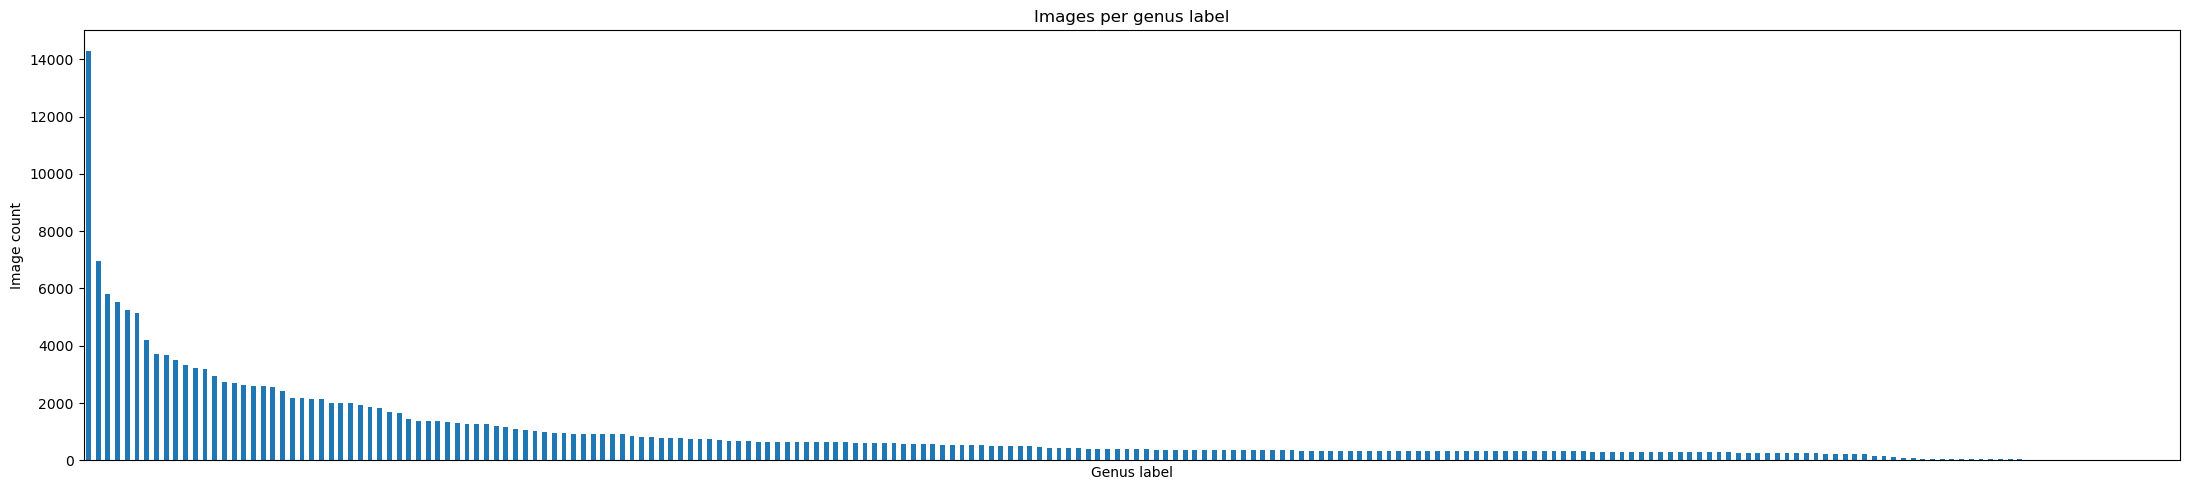

In [66]:
# genus counts
species_plot_counts = df["genus"].value_counts()

# plot image count per genus label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per genus label"
)

# labels and display
plt.xlabel("Genus label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()

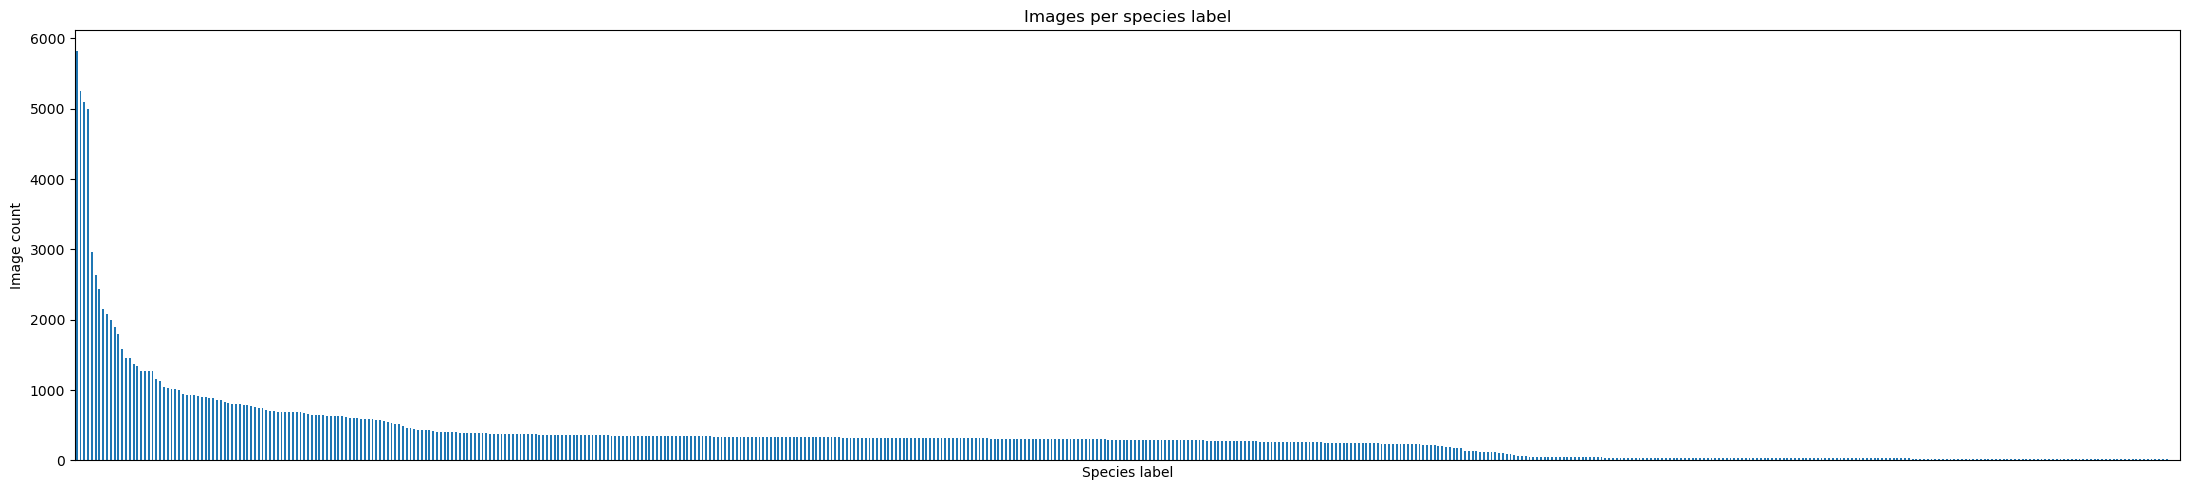

In [67]:
# species counts
species_plot_counts = df["folder"].value_counts()

# plot image count per species label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per species label"
)

# labels and display
plt.xlabel("Species label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()

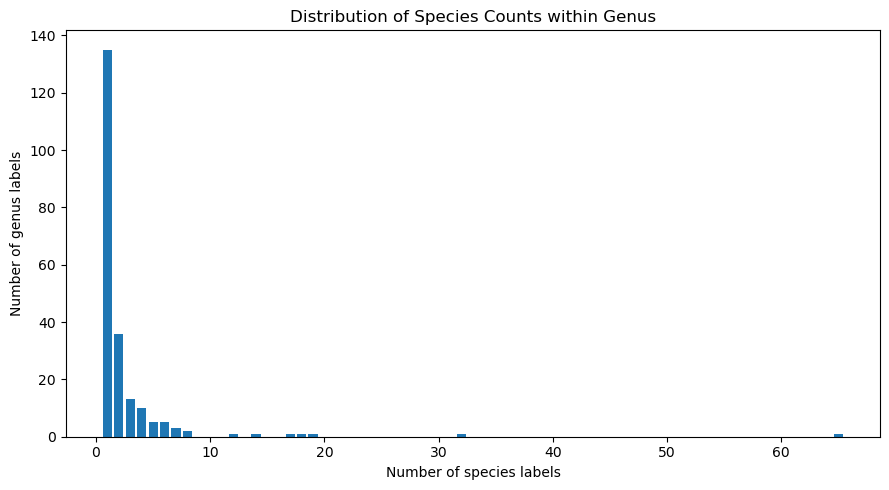

In [68]:
# count how many genus labels have 1, 2, 3, ... species labels
species_per_genus_distribution = (
    genus_counts["species_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# clean column names for plotting
species_per_genus_distribution.columns = [
    "species_labels_per_genus",
    "genus_count"
]

# slot for plot 
plt.figure(figsize=(9, 5))

# bar plot x and y for distribution check
plt.bar(
    species_per_genus_distribution["species_labels_per_genus"],
    species_per_genus_distribution["genus_count"]
)

# labels and display
plt.title("Distribution of Species Counts within Genus")
plt.xlabel("Number of species labels")
plt.ylabel("Number of genus labels")
plt.tight_layout()
plt.show()

### Image size checks

- summary of width/height/aspect-ratio
- unique size combinations, cumulative value for each combination for PyTorch transform; necessity check
- frequency of images distribution by unique sizes

In [69]:
# simple summary statistics
size_metric_summary = (
    df[["width", "height", "aspect_ratio"]]
    .agg(["min", "max", "median", "mean", "std"])
)

# add mode calculation
size_metric_summary.loc["mode"] = (
    df[["width", "height", "aspect_ratio"]]
    .mode()
    .iloc[0]
)

size_metric_summary

,width,height,aspect_ratio
min,90.000000,90.000000,0.252000
max,500.000000,500.000000,4.385965
median,333.000000,331.000000,1.000000
mean,340.259208,326.220458,1.070949
std,123.922141,115.129194,0.274597
mode,224.000000,224.000000,1.000000


In [70]:
# count each unique width/height/aspect-ratio combo
size_combinations = (
    df.groupby(["width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# percent of total images for each size combo
size_combinations["percent_total"] = (
    size_combinations["image_count"] / len(df) * 100
)

# running percent to see how quickly common sizes add up
size_combinations["cumulative_percent"] = (
    size_combinations["percent_total"].cumsum()
)

size_combinations

,width,height,aspect_ratio,image_count,percent_total,cumulative_percent
0,224,224,1.000000,83614,42.788789,42.788789
1,500,375,1.333333,31288,16.011381,58.800170
2,375,500,0.750000,28257,14.460291,73.260461
3,500,333,1.501502,9216,4.716214,77.976675
4,281,500,0.562000,3529,1.805937,79.782612
...,...,...,...,...,...,...
1139,500,175,2.857143,1,0.000512,99.997953
1140,500,174,2.873563,1,0.000512,99.998465
1141,500,170,2.941176,1,0.000512,99.998977
1142,500,150,3.333333,1,0.000512,99.999488


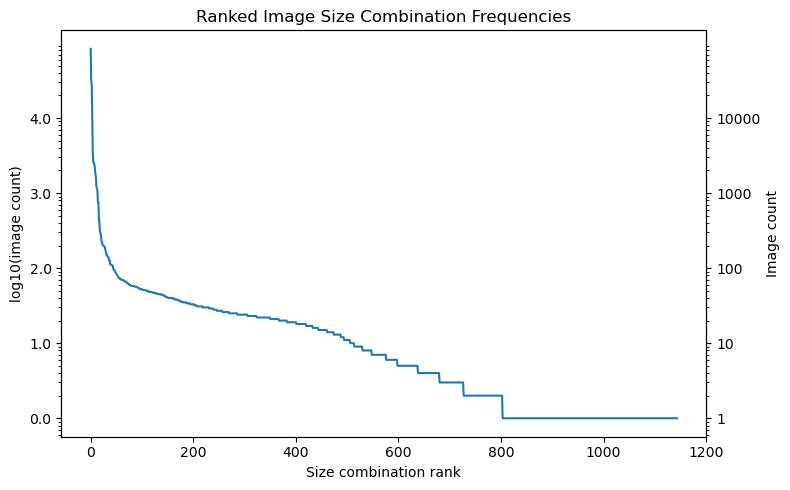

In [71]:
# raw values for log interpretation
tick_values = [1, 10, 100, 1000, 10000, 100000]
tick_values = [x for x in tick_values if x <= size_combinations["image_count"].max()]

# slot for plot 
fig, ax = plt.subplots(figsize=(8, 5))

# plot size combinations ranked by image count
ax.plot(size_combinations["image_count"].values)

# left axis as log10 values
ax.set_yscale("log")
ax.set_yticks(tick_values)
ax.set_yticklabels([round(math.log10(x), 2) for x in tick_values])
ax.set_ylabel("log10(image count)")

# right axis as raw image counts
ax_right = ax.twinx()
ax_right.set_yscale("log")
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(tick_values)
ax_right.set_yticklabels([str(x) for x in tick_values])
ax_right.set_ylabel("Image count")

# labels and display
ax.set_title("Ranked Image Size Combination Frequencies")
ax.set_xlabel("Size combination rank")
plt.tight_layout()
plt.show()

- Original images vary in size, PyTorch will need to handle resizing during loading

---

## Visual Checks
This section looks directly at images to confirm EDA findings before moving on

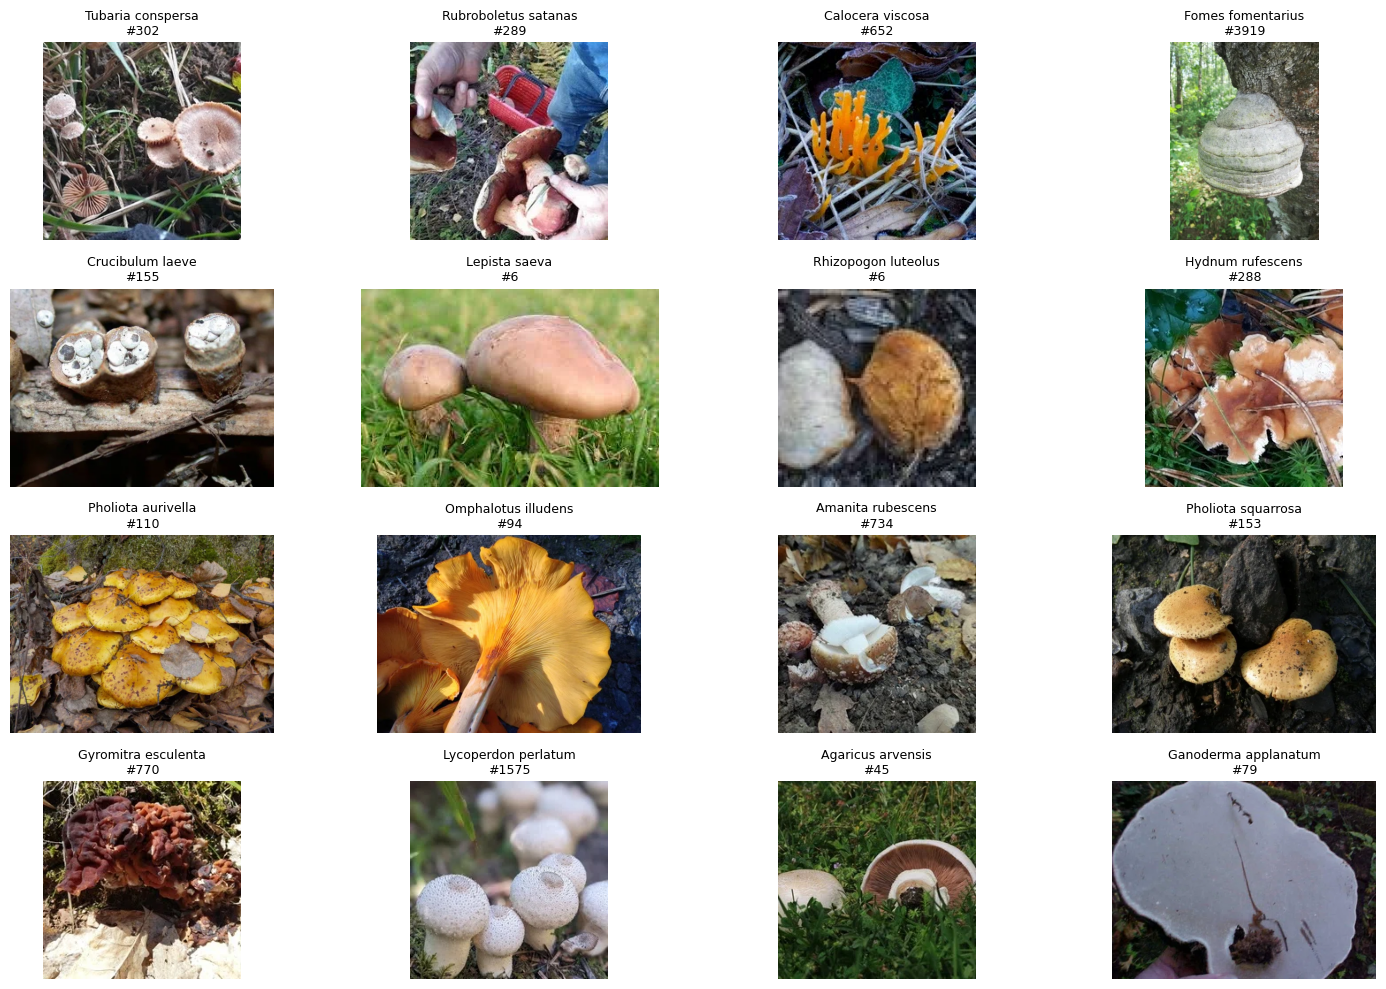

In [78]:
# random sample 16 images
sample_images = df.sample(n=16, random_state=SEED)

# create emtpy slots for images
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes = axes.flatten()

# put images into slots with file name
for ax, (_, row) in zip(axes, sample_images.iterrows()):

    path = Path(str(row["file_path"]).replace("\\", "/"))

    if not path.exists():
        ax.set_title("Missing")
        ax.axis("off")
        continue

    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{row['folder']}\n#{row['img_number']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

---

### Early modeling decision:
Images will contain backgrounds for model to learn since mushrooms grow in different climates and different substrates (different tree types, grassy, mulch, leafy, environments like hilly, mountainous, river etc.)

### Going towards ImageFolder
- The class label for modeling will be the folder label, not genus/species separated.
- Will use resnet18 pretrained imagenet 1k for standard image features like edges, textures, shapes, etc.
- Transforms will standardize image shape during loading, as well as normalization with mean and std for pretrained model expectations (according to: https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).
- Train/test split must account for imbalance ; stratified.
- Label noise is expected and will be audited later using embeddings/clustering/model disagreement.

### Transforms, and load

In [73]:
# baseline transform for pretrained ResNet18
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load folder-labeled image dataset through PyTorch
image_dataset = ImageFolder(
    root=image_folder,
    transform=baseline_transform
)

# compare PyTorch load against metadata table
# to check if image loader sees the same number of images and folders
print("ImageFolder images:", len(image_dataset))
print("DataFrame images:", len(df))

print("ImageFolder classes:", len(image_dataset.classes))
print("DataFrame folder labels:", df["folder"].nunique())

ImageFolder images: 195411
DataFrame images: 195411
ImageFolder classes: 555
DataFrame folder labels: 555


### Train/val/test splits (70/15/15)

In [74]:
# split settings
random_state = SEED
train_size = 0.70
val_size = 0.15
test_size = 0.15

# ImageFolder numeric labels
targets = image_dataset.targets
indices = list(range(len(image_dataset)))

# split one: train and holdout
train_indices, holdout_indices, train_targets, holdout_targets = train_test_split(
    indices,
    targets,
    train_size=train_size,
    stratify=targets,
    random_state=random_state
)

# split two: holdout into validation/test
val_indices, test_indices = train_test_split(
    holdout_indices,
    test_size=test_size / (val_size + test_size),
    stratify=holdout_targets,
    random_state=random_state
)

# create PyTorch dataset subsets
train_dataset = Subset(image_dataset, train_indices)
val_dataset = Subset(image_dataset, val_indices)
test_dataset = Subset(image_dataset, test_indices)

print("train images:", len(train_dataset))
print("validation images:", len(val_dataset))
print("test images:", len(test_dataset))
print("total images:", len(train_dataset) + len(val_dataset) + len(test_dataset))

train images: 136787
validation images: 29312
test images: 29312
total images: 195411


### Dataloaders

In [75]:
# loader settings
batch_size = 32
num_workers = 0  # safer for Windows/Jupyter

# dataloaders for each split
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 4275
validation batches: 916
test batches: 916


### Baseline CNN

In [76]:
# device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# number of folder-based classes
num_classes = len(image_dataset.classes)

# pretrained baseline CNN
model = models.resnet18(weights="DEFAULT")

# replace final layer for mushroom class count
model.fc = nn.Linear(model.fc.in_features, num_classes)

# move model to device
model = model.to(device)

print("device:", device)
print("number of classes:", num_classes)

device: cpu
number of classes: 555


---